Explained variance ratio:  [0.98399484 0.01600516]


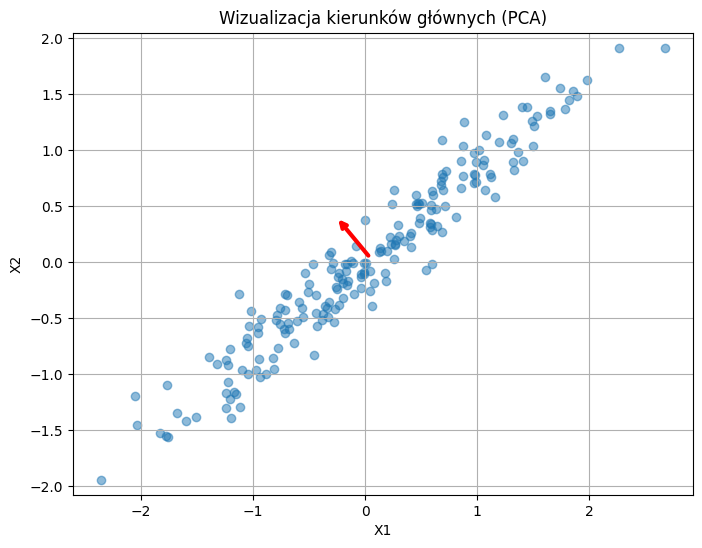

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.random.randn(200,2)
X[:,1] = X[:,0]*0.8 + np.random.randn(200)*0.2
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
print("Explained variance ratio: ", pca.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Dane')
mu = pca.mean_
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    plt.annotate('', mu + v, mu, arrowprops=dict(arrowstyle='->', linewidth=3, color='red'))
plt.axis('equal')
plt.title('Wizualizacja kierunków głównych (PCA)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


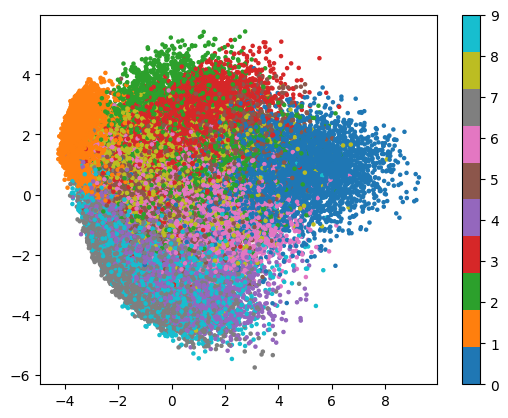

In [6]:
from tensorflow.keras.datasets import mnist
(X_train,y_train), (_,_) = mnist.load_data()
X = X_train.reshape(X_train.shape[0],-1)/255.0
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
plt.scatter(X_reduced[:,0],X_reduced[:,1],c=y_train,cmap='tab10',s=5)
plt.colorbar()
plt.show()

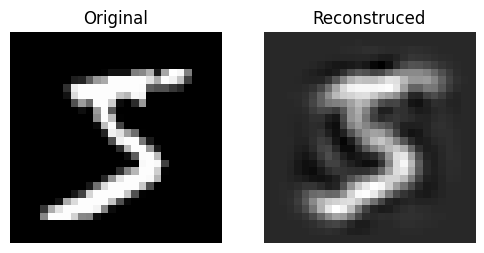

In [8]:
pca = PCA(n_components=50)

X_50 = pca.fit_transform(X)
X_recon = pca.inverse_transform(X_50)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(X[0].reshape(28,28),cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(X_recon[0].reshape(28,28),cmap='gray')
plt.title("Reconstruced")
plt.axis('off')
plt.show()

Number of components:  10 | Explained variance: 0.4881
Number of components:  20 | Explained variance: 0.6436
Number of components:  50 | Explained variance: 0.8246
Number of components: 100 | Explained variance: 0.9146
Number of components: 200 | Explained variance: 0.9664
Number of components: 500 | Explained variance: 0.9993


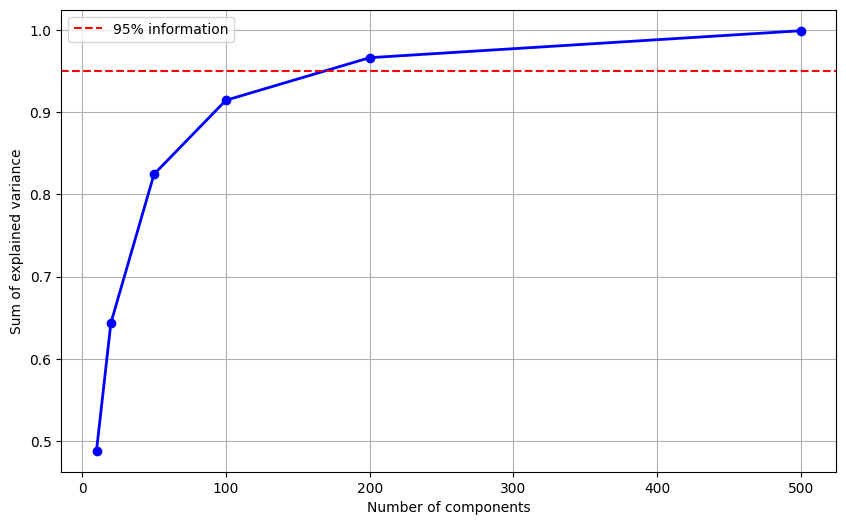

In [11]:
components_list = [10, 20, 50, 100, 200, 500]
explained_variances = []

for n in components_list:
    pca = PCA(n_components=n)
    pca.fit(X)
    total_variance = np.sum(pca.explained_variance_ratio_)
    explained_variances.append(total_variance)
    print(f"Number of components: {n:3} | Explained variance: {total_variance:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(components_list, explained_variances, 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% information')
plt.xlabel('Number of components')
plt.ylabel('Sum of explained variance')
plt.legend()
plt.grid(True)
plt.show()

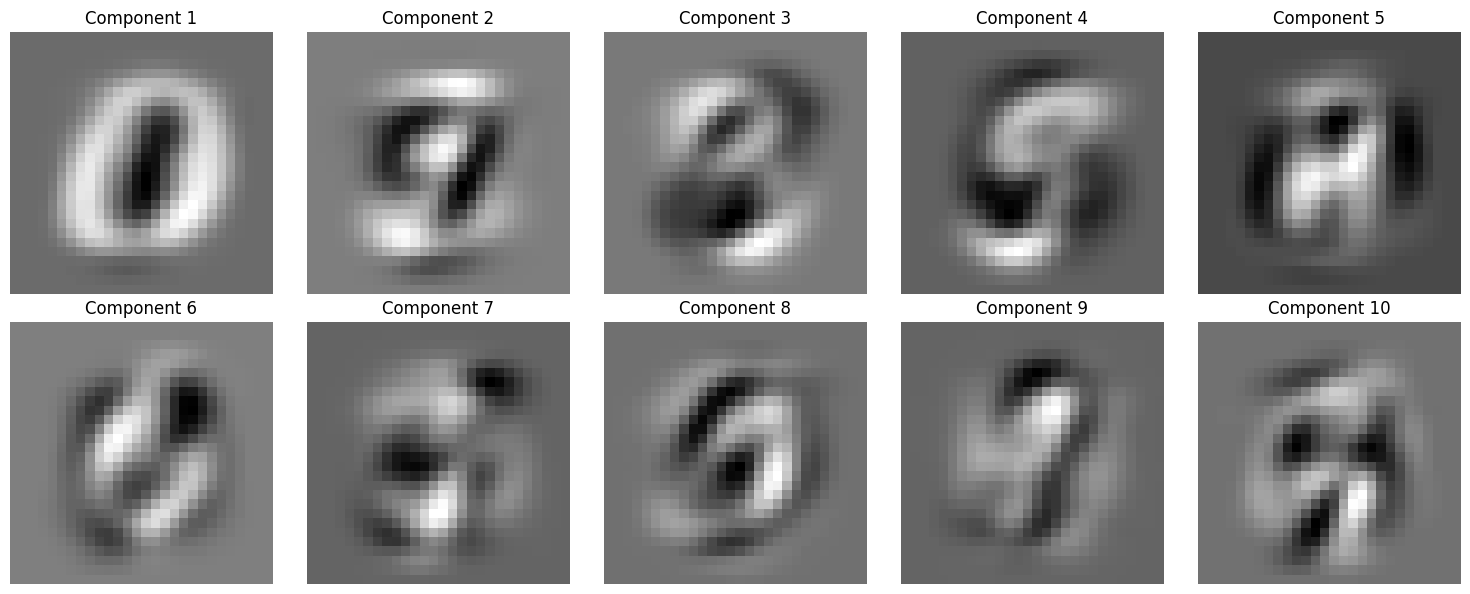

In [12]:
pca = PCA(n_components=10)
pca.fit(X)
eigenvectors = pca.components_

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = eigenvectors[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f'Component {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

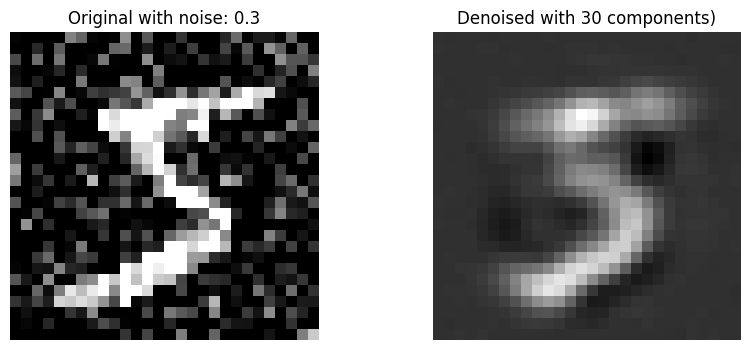

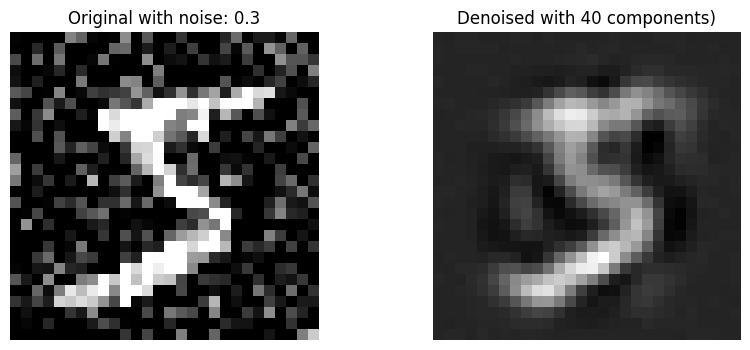

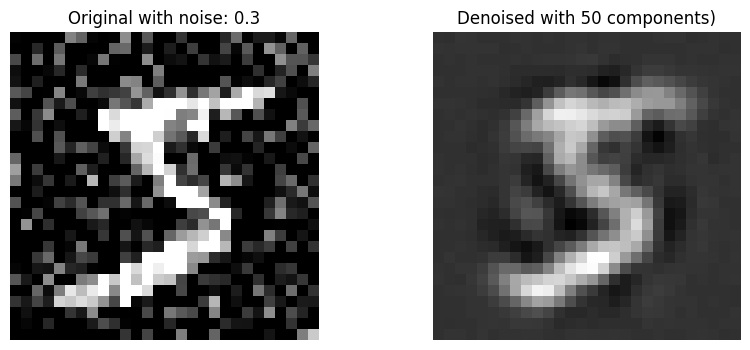

In [29]:
noise_factor = 0.3
X_noisy = X + noise_factor*np.random.normal(loc=0.0, scale=1.0, size=X.shape)
X_noisy = np.clip(X_noisy, 0., 1.)

n_components = [30,40,50]
for n in n_components:
  pca = PCA(n_components=n)
  X_reduced = pca.fit_transform(X_noisy)
  X_denoised = pca.inverse_transform(X_reduced)

  plt.figure(figsize=(10, 4))
  plt.subplot(1, 2, 1)
  plt.imshow(X_noisy[0].reshape(28, 28), cmap='gray')
  plt.title(f"Original with noise: {noise_factor}")
  plt.axis('off')
  plt.subplot(1, 2, 2)
  plt.imshow(X_denoised[0].reshape(28, 28), cmap='gray')
  plt.title(f"Denoised with {n} components)")
  plt.axis('off')
  plt.show()

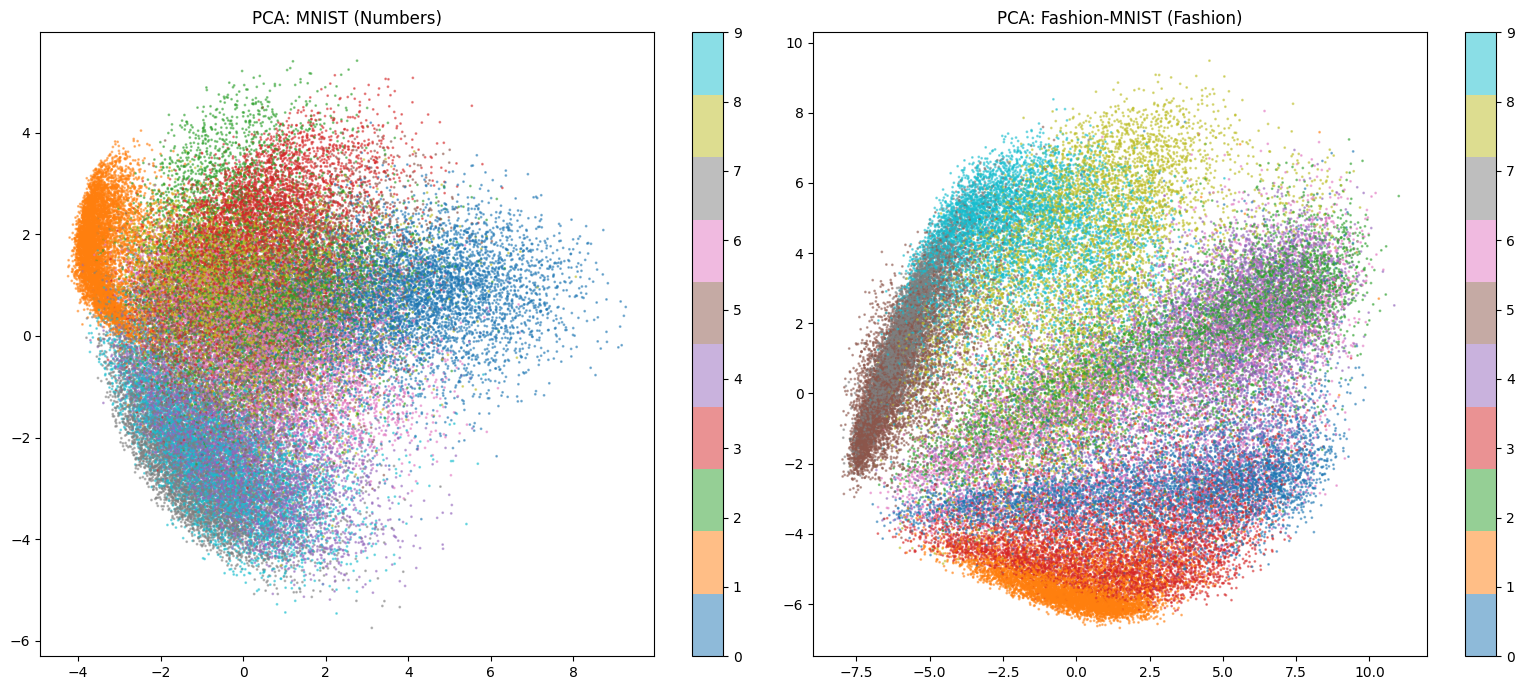

In [31]:
from tensorflow.keras.datasets import fashion_mnist

(X_m, y_m), _ = mnist.load_data()
(X_f, y_f), _ = fashion_mnist.load_data()

X_m = X_m.reshape(X_m.shape[0], -1) / 255.0
X_f = X_f.reshape(X_f.shape[0], -1) / 255.0

pca = PCA(n_components=2)
X_m_pca = pca.fit_transform(X_m)
X_f_pca = pca.fit_transform(X_f)

plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
scatter_m = plt.scatter(X_m_pca[:, 0], X_m_pca[:, 1], c=y_m, cmap='tab10', s=1, alpha=0.5)
plt.title("PCA: MNIST (Numbers)")
plt.colorbar(scatter_m)
plt.subplot(1, 2, 2)
scatter_f = plt.scatter(X_f_pca[:, 0], X_f_pca[:, 1], c=y_f, cmap='tab10', s=1, alpha=0.5)
plt.title("PCA: Fashion-MNIST (Fashion)")
plt.colorbar(scatter_f)
plt.tight_layout()
plt.show()